# 🧠 CIB-Net: EEG-Based Emotion Recognition
## Cross-Subject Brain Intelligence Network | DEAP Dataset | RTX 4050

| Item | Detail |
|---|---|
| **Model** | CIB-Net (Per-Channel CNN + Region-Grouped Fusion) |
| **Dataset** | DEAP — `D:/EEG_5Stages/deap-dataset/data_preprocessed_python` |
| **Protocol** | Leave-One-Subject-Out (LOSO) — 32 folds |
| **GPU Target** | NVIDIA RTX 4050 (Ada Lovelace, CUDA 12.1) |
| **Environment** | Isolated venv — `D:/EEG_5Stages/venv` |
| **AMP** | Mixed Precision Training ⚡ enabled |

> ⚠️ **Before running this notebook**, make sure you ran `setup_env.ps1` once  
> and selected the kernel **"CIB-Net EEG (RTX 4050)"** from Kernel → Change Kernel.

### 📋 Steps
| # | Cell | Checkpoint Saved |
|---|---|---|
| 1 | Environment Sanity Check | — |
| 2 | GPU & CUDA Detection | — |
| 3 | Imports | — |
| 4 | Preprocessing Functions | — |
| 5 | Dataset Class | — |
| 6 | Configuration | — |
| 7 | Load Dataset | 💾 `checkpoints/dataset_checkpoint.npz` |
| 8 | CIB-Net Architecture | — |
| 9 | Loss Functions & Metrics | — |
| 10 | LOSO Training | 💾 `checkpoints/fold_XX_best.pth` · `fold_metrics.json` |
| 11 | Results & Plots | 💾 `checkpoints/cib_net_final_results.json` |

## ✅ Step 1 — Environment Sanity Check

Verifies that:
- You are running inside the **isolated CIB-Net venv** (not system Python)
- All required packages are importable with the correct versions
- The DEAP dataset folder exists and has all 32 `.dat` files

> If any check fails, re-run `setup_env.ps1` then restart the kernel.

In [3]:
import sys, os, importlib

# ── Venv check ───────────────────────────────────────────────
EXPECTED_VENV = os.path.normpath(r"D:/EEG_5Stages/venv")
current_prefix = os.path.normpath(sys.prefix)
in_venv = current_prefix.lower() == EXPECTED_VENV.lower()

print("=" * 58)
print("  ENVIRONMENT SANITY CHECK")
print("=" * 58)
print(f"  Python executable : {sys.executable}")
print(f"  sys.prefix        : {sys.prefix}")
if in_venv:
    print("  Venv status       : ✅  Correct isolated venv")
else:
    print("  Venv status       : ⚠️  NOT in expected venv!")
    print(f"                      Expected: {EXPECTED_VENV}")
    print("  → Kernel > Change Kernel > 'CIB-Net EEG (RTX 4050)'")

# ── Package version check (relaxed for Python 3.13) ─────────
REQUIRED = ["torch", "numpy", "scipy", "networkx", "sklearn", "tqdm", "matplotlib", "seaborn"]
print()
all_ok = True
for pkg in REQUIRED:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "?")
        print(f"  ✅  {pkg:<14} installed={ver:<12}")
    except ImportError:
        print(f"  ❌  {pkg:<14} NOT FOUND — run setup_env.ps1 again")
        all_ok = False

# ── Dataset path check ───────────────────────────────────────
DATA_PATH = r"D:/EEG_5Stages/deap-dataset/data_preprocessed_python"
print()
if os.path.exists(DATA_PATH):
    dats = sorted(f for f in os.listdir(DATA_PATH) if f.endswith(".dat"))
    print(f"  ✅  Dataset path   : {DATA_PATH}")
    print(f"  ✅  .dat files     : {len(dats)} found  ({dats[0]} … {dats[-1]})")
else:
    print(f"  ❌  Dataset path not found: {DATA_PATH}")
    all_ok = False

print()
print("=" * 58)
if all_ok:
    print("  🎉  All checks passed — ready to train!")
else:
    print("  ⚠️   Some checks failed — fix issues above before continuing.")
print("=" * 58)


  ENVIRONMENT SANITY CHECK
  Python executable : d:\EEG_5Stages\venv\Scripts\python.exe
  sys.prefix        : d:\EEG_5Stages\venv
  Venv status       : ✅  Correct isolated venv

  ✅  torch          installed=2.6.0+cu124 
  ✅  numpy          installed=2.5.3       
  ✅  scipy          installed=1.18.1      
  ✅  networkx       installed=3.7         
  ✅  sklearn        installed=1.9.1       
  ✅  tqdm           installed=4.70.1      
  ✅  matplotlib     installed=3.11.2      
  ✅  seaborn        installed=0.13.2      

  ✅  Dataset path   : D:/EEG_5Stages/deap-dataset/data_preprocessed_python
  ✅  .dat files     : 32 found  (s01.dat … s32.dat)

  🎉  All checks passed — ready to train!


## 🖥️ Step 2 — GPU & CUDA Detection

In [4]:
import torch

sep = "=" * 52
print(sep)
print(f"  PyTorch Version   : {torch.__version__}")
print(f"  CUDA Available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"  GPU Name          : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version      : {torch.version.cuda}")
    print(f"  Compute Cap.      : {gpu.major}.{gpu.minor}")
    print(f"  Total VRAM        : {gpu.total_memory / 1e9:.2f} GB")
    print(f"  SM Count          : {gpu.multi_processor_count}")
    print(f"  AMP Tensor Cores  : ✅  (Ada Lovelace / RTX 4050)")
    device  = torch.device("cuda")
    USE_AMP = True
else:
    print("  ⚠️  No CUDA GPU found — falling back to CPU (slow).")
    device  = torch.device("cpu")
    USE_AMP = False

print(sep)
print(f"\n🔥 Active device : {device}")
if USE_AMP:
    print("⚡  Mixed Precision (AMP) ENABLED — ~1.5–2× speedup on RTX 4050")


  PyTorch Version   : 2.6.0+cu124
  CUDA Available    : True
  GPU Name          : NVIDIA GeForce RTX 4050 Laptop GPU
  CUDA Version      : 12.4
  Compute Cap.      : 8.9
  Total VRAM        : 6.44 GB
  SM Count          : 20
  AMP Tensor Cores  : ✅  (Ada Lovelace / RTX 4050)

🔥 Active device : cuda
⚡  Mixed Precision (AMP) ENABLED — ~1.5–2× speedup on RTX 4050


## 📚 Step 3 — Import Libraries

In [5]:
import os, pickle, json, warnings
import numpy as np
from scipy.signal import butter, filtfilt, hilbert
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score, confusion_matrix)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
print("✅  All imports successful.")


✅  All imports successful.


## 🔧 Step 4 — Preprocessing Functions

Pipeline applied to every subject:
1. **Butterworth Bandpass Filter** — 4–45 Hz (removes DC drift & high-freq noise)
2. **Baseline Correction** — subtract 3-second pre-stimulus mean per channel
3. **Z-score Normalization** — zero-mean, unit-variance per trial
4. **PLV Centrality** — Phase Locking Value matrix → eigenvector centrality (graph feature)

In [6]:
def butter_bandpass_filter(data, lowcut=4.0, highcut=45.0, fs=128, order=4):
    """4th-order Butterworth bandpass filter applied along last axis."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, data, axis=-1)


def preprocess_eeg(eeg_data, fs=128, baseline_sec=3):
    """
    Filter → baseline-correct → z-score.
    Input : (n_trials, n_channels, n_samples)
    Output: (n_trials, n_channels, n_samples - baseline_samples)
    """
    filtered = butter_bandpass_filter(eeg_data, fs=fs)
    bs = baseline_sec * fs
    baseline  = np.mean(filtered[:, :, :bs], axis=-1, keepdims=True)
    corrected = filtered[:, :, bs:] - baseline
    mean = np.mean(corrected, axis=-1, keepdims=True)
    std  = np.std(corrected,  axis=-1, keepdims=True)
    return (corrected - mean) / (std + 1e-8)


def compute_plv_centrality(eeg_data):
    """
    PLV matrix → eigenvector centrality.
    Input : (n_channels, n_samples)
    Output: centrality vector (n_channels,)
    """
    C = eeg_data.shape[0]
    phase = np.angle(hilbert(eeg_data, axis=1))
    plv   = np.zeros((C, C))
    for i in range(C):
        for j in range(i + 1, C):
            v = np.abs(np.mean(np.exp(1j * (phase[i] - phase[j]))))
            plv[i, j] = plv[j, i] = v
    np.fill_diagonal(plv, 1.0)
    G = nx.from_numpy_array(plv)
    try:
        c = nx.eigenvector_centrality_numpy(G, weight="weight")
        return np.array([c[i] for i in range(C)])
    except Exception:
        return np.ones(C) / C


print("✅  Preprocessing functions defined.")


✅  Preprocessing functions defined.


## 📂 Step 5 — Dataset Class

`DEAPDataset`:
- Reads `s01.dat` … `s32.dat` from the DEAP folder (pickle / `latin1` encoding)
- Extracts 32 EEG channels (indices 0–31 out of 40 total signals)
- Applies full preprocessing pipeline per subject
- Computes per-trial PLV centrality vector
- Binarises valence/arousal at threshold = 5  →  0 (low) / 1 (high)

In [7]:
class DEAPDataset(Dataset):
    """DEAP EEG emotion dataset — loads & preprocesses all 32 subjects."""

    def __init__(self, data_path, target="valence"):
        self.x, self.y, self.subject_ids, self.plv = [], [], [], []
        files = sorted(f for f in os.listdir(data_path)
                       if f.startswith("s") and f.endswith(".dat"))
        print(f"  Found {len(files)} subject files in {data_path}")

        for fname in tqdm(files, desc="Loading & preprocessing"):
            sid = int(fname[1:3])
            with open(os.path.join(data_path, fname), "rb") as fh:
                content = pickle.load(fh, encoding="latin1")

            data, labels = content["data"], content["labels"]
            eeg   = preprocess_eeg(data[:, :32, :])          # (40, 32, T)
            tidx  = 0 if target == "valence" else 1
            y_bin = (labels[:, tidx] > 5).astype(np.int64)

            self.x.append(eeg)
            self.y.append(y_bin)
            self.subject_ids.extend([sid] * 40)
            for trial in eeg:
                self.plv.append(compute_plv_centrality(trial))

        self.x           = np.concatenate(self.x,  axis=0)
        self.y           = np.concatenate(self.y,  axis=0)
        self.subject_ids = np.array(self.subject_ids)
        self.plv         = np.array(self.plv)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.x[idx],           dtype=torch.float32),
            torch.tensor(self.y[idx],           dtype=torch.long),
            torch.tensor(self.subject_ids[idx], dtype=torch.long),
            torch.tensor(self.plv[idx],         dtype=torch.float32),
        )


def get_dataloaders(dataset, train_idx, test_idx, batch_size=16):
    """Build SubsetRandomSampler-based train/test DataLoaders."""
    kw = dict(batch_size=batch_size, num_workers=0, pin_memory=True)
    return (
        DataLoader(dataset, sampler=torch.utils.data.SubsetRandomSampler(train_idx), **kw),
        DataLoader(dataset, sampler=torch.utils.data.SubsetRandomSampler(test_idx),  **kw),
    )


print("✅  DEAPDataset + DataLoader helpers defined.")


✅  DEAPDataset + DataLoader helpers defined.


## ⚙️ Step 6 — Configuration

The dataset path is pre-set to your local folder.  
Adjust `TARGET`, `EPOCHS`, or `BATCH_SIZE` if needed.

In [8]:
# ============================================================
# ⚙️  CONFIGURATION
# ============================================================

# Dataset — auto-set to your local DEAP folder
DATA_PATH = r"D:/EEG_5Stages/deap-dataset/data_preprocessed_python"

TARGET     = "valence"    # "valence" or "arousal"

# Training hyperparameters
BATCH_SIZE   = 16         # Safe for RTX 4050 (6 GB VRAM)
EPOCHS       = 50
LR           = 1e-4
LAMBDA_GRAPH = 0.01       # Graph-consistency loss weight
LAMBDA_SD    = 0.1        # Spectral-decoupling base weight

# Checkpoints go alongside the dataset root
CKPT_DIR = r"D:/EEG_5Stages/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ============================================================
print("=" * 50)
print(f"  DATA_PATH  : {DATA_PATH}")
print(f"  TARGET     : {TARGET}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  EPOCHS     : {EPOCHS}")
print(f"  LR         : {LR}")
print(f"  USE_AMP    : {USE_AMP}  (RTX 4050 mixed precision)")
print(f"  CKPT_DIR   : {CKPT_DIR}")
print("=" * 50)

# Confirm .dat files are accessible
dats = sorted(f for f in os.listdir(DATA_PATH) if f.endswith(".dat"))
print(f"\n✅  {len(dats)} .dat files confirmed: {dats[0]} … {dats[-1]}")


  DATA_PATH  : D:/EEG_5Stages/deap-dataset/data_preprocessed_python
  TARGET     : valence
  BATCH_SIZE : 16
  EPOCHS     : 50
  LR         : 0.0001
  USE_AMP    : True  (RTX 4050 mixed precision)
  CKPT_DIR   : D:/EEG_5Stages/checkpoints

✅  32 .dat files confirmed: s01.dat … s32.dat


## 💾 Step 7 — Load Dataset  *(Smart Checkpoint)*

| Run | What happens |
|---|---|
| **First time** | Preprocesses all 32 subjects + computes PLV (~15–30 min), saves `.npz` |
| **Subsequent** | Loads from `checkpoints/dataset_checkpoint.npz` in < 30 seconds |

> 💡 Delete `dataset_checkpoint.npz` to force a full reload.

In [9]:
DATASET_CKPT = os.path.join(CKPT_DIR, "dataset_checkpoint.npz")

if os.path.exists(DATASET_CKPT):
    print("✅  Checkpoint found — loading preprocessed arrays (fast path)...")
    ck = np.load(DATASET_CKPT, allow_pickle=True)
    dataset = DEAPDataset.__new__(DEAPDataset)
    dataset.x           = ck["x"]
    dataset.y           = ck["y"]
    dataset.subject_ids = ck["subject_ids"]
    dataset.plv         = ck["plv"]
    print("    Loaded from:", DATASET_CKPT)
else:
    print("⏳  No checkpoint found — running full preprocessing...")
    print("    (This takes ~15–30 min. Grab a coffee ☕)")
    dataset = DEAPDataset(data_path=DATA_PATH, target=TARGET)
    np.savez_compressed(
        DATASET_CKPT,
        x           = dataset.x,
        y           = dataset.y,
        subject_ids = dataset.subject_ids,
        plv         = dataset.plv,
    )
    print(f"\n💾  Dataset checkpoint saved → {DATASET_CKPT}")
    print("    Next run will load in < 30 seconds.")

print(f"\n📊  Dataset Summary")
print(f"    Total trials     : {len(dataset)}")
print(f"    Unique subjects  : {len(np.unique(dataset.subject_ids))}")
print(f"    EEG channels     : {dataset.x.shape[1]}")
print(f"    Time samples     : {dataset.x.shape[2]}")
print(f"    Label dist (0/1) : {np.bincount(dataset.y)}")


✅  Checkpoint found — loading preprocessed arrays (fast path)...
    Loaded from: D:/EEG_5Stages/checkpoints\dataset_checkpoint.npz

📊  Dataset Summary
    Total trials     : 1280
    Unique subjects  : 32
    EEG channels     : 32
    Time samples     : 7680
    Label dist (0/1) : [1011  269]


## 🏗️ Step 8 — CIB-Net Architecture

```
Input  (B, 32 channels, T samples)
   │
   ▼  PerChannelCNNEncoder
      Conv1d(1→32,  k=25) → BN → ELU
      Conv1d(32→64, k=15) → BN → ELU → AdaptiveAvgPool(64)
      Conv1d(64→128, k=7) → BN → ELU → AdaptiveAvgPool(1)
   Output: (B, 32, 128)
   │
   ▼  RegionGroupedFusion  [5 neurophysiological regions]
      Frontal   {0,1,2,3,16,17,18} ─┐
      Temporal  {4,5,12,13}         ─┤  intra-region attention
      Central   {6,7,19,20,21}      ─┤  → pooled (B, 128)
      Parietal  {8,9,22,23}         ─┤  → aux logits
      Occipital {10,11,24,25}       ─┘
      concat(5×128) → Linear → 2 classes
```

In [10]:
class PerChannelCNNEncoder(nn.Module):
    """Encodes each EEG channel independently into a d_embed-dimensional vector."""
    def __init__(self, d_embed=128, n_channels=32):
        super().__init__()
        self.d_embed = d_embed
        self.encoder = nn.Sequential(
            nn.Conv1d(1,      32,     kernel_size=25, padding=12), nn.BatchNorm1d(32),     nn.ELU(),
            nn.Conv1d(32,     64,     kernel_size=15, padding=7),  nn.BatchNorm1d(64),     nn.ELU(),
            nn.AdaptiveAvgPool1d(64),
            nn.Conv1d(64, d_embed,    kernel_size=7,  padding=3),  nn.BatchNorm1d(d_embed),nn.ELU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        B, C, T = x.size()
        out = self.encoder(x.view(B * C, 1, T))   # (B*C, d_embed, 1)
        return out.view(B, C, self.d_embed)         # (B, C, d_embed)


class RegionGroupedFusion(nn.Module):
    """Brain-region attention fusion with per-region auxiliary classifiers."""
    REGIONS = {
        "frontal":   [0,  1,  2,  3,  16, 17, 18],
        "temporal":  [4,  5,  12, 13],
        "central":   [6,  7,  19, 20, 21],
        "parietal":  [8,  9,  22, 23],
        "occipital": [10, 11, 24, 25],
    }

    def __init__(self, d_embed=128, n_classes=2):
        super().__init__()
        self.regions = self.REGIONS
        self.intra_attentions = nn.ModuleDict({
            r: nn.Sequential(
                nn.Linear(d_embed, d_embed // 2), nn.Tanh(),
                nn.Linear(d_embed // 2, 1),       nn.Softmax(dim=1),
            ) for r in self.regions
        })
        self.group_classifiers = nn.ModuleDict({
            r: nn.Linear(d_embed, n_classes) for r in self.regions
        })
        self.final_classifier = nn.Linear(len(self.regions) * d_embed, n_classes)

    def forward(self, x_embed):
        feats, g_logits = [], []
        for region, chs in self.regions.items():
            rx     = x_embed[:, chs, :]                    # (B, rc, d)
            attn   = self.intra_attentions[region](rx)     # (B, rc, 1)
            pooled = torch.sum(rx * attn, dim=1)           # (B, d)
            feats.append(pooled)
            g_logits.append(self.group_classifiers[region](pooled))
        return self.final_classifier(torch.cat(feats, dim=1)), g_logits


class CIBNet(nn.Module):
    """CIB-Net: Cross-subject Invariant Brain-region Network."""
    def __init__(self):
        super().__init__()
        self.encoder = PerChannelCNNEncoder()
        self.fusion  = RegionGroupedFusion()

    def forward(self, x):
        emb         = self.encoder(x)                          # (B, 32, D)
        learned_imp = torch.norm(emb, dim=2).mean(dim=0)      # (32,)
        logits, g   = self.fusion(emb)
        return logits, g, learned_imp


# Quick param count
_m = CIBNet()
_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"✅  CIB-Net defined  |  Trainable params: {_p:,}")
del _m


✅  CIB-Net defined  |  Trainable params: 133,713


## 📉 Step 9 — Loss Functions & Metrics

| Function | Role |
|---|---|
| `SpectralDecouplingLoss` | Cross-entropy + spectral-decoupling penalty (weighted by inverse invariance) |
| `compute_dynamic_invariance` | Measures inter-subject variance per brain region → invariance score |
| `compute_graph_consistency_loss` | Cosine alignment between learned channel importance and PLV centrality |
| `compute_metrics` | Accuracy, Macro-F1, Precision, Recall, Δ-trivial, Confusion Matrix |

In [11]:
class SpectralDecouplingLoss(nn.Module):
    def __init__(self, lambda_base=0.1, class_weights=None):
        super().__init__()
        self.ce          = nn.CrossEntropyLoss(weight=class_weights)
        self.lambda_base = lambda_base

    def forward(self, logits, y, group_logits, inv_scores):
        penalty = sum(
            (self.lambda_base / (inv_scores[k] + 1e-4)) * torch.mean(z ** 2)
            for k, z in enumerate(group_logits)
        )
        return self.ce(logits, y) + penalty


def compute_dynamic_invariance(group_logits, subj_ids):
    unique = torch.unique(subj_ids)
    if len(unique) <= 1:
        return torch.ones(len(group_logits), device=group_logits[0].device)
    variances = []
    for z in group_logits:
        mags = torch.norm(z, dim=1)
        subj_means = torch.stack([mags[subj_ids == s].mean() for s in unique])
        variances.append(torch.var(subj_means))
    variances = torch.stack(variances)
    v_min, v_max = variances.min(), variances.max()
    norm = ((variances - v_min) / (v_max - v_min + 1e-8)
            if v_max > v_min else torch.zeros_like(variances))
    return 1.0 - norm


def compute_graph_consistency_loss(learned_imp, plv_centrality):
    cos = F.cosine_similarity(learned_imp.unsqueeze(0), plv_centrality)
    return (1.0 - cos).mean()


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    maj = np.max(np.unique(y_true, return_counts=True)[1]) / len(y_true)
    return {
        "accuracy":           float(acc),
        "macro_f1":           float(f1_score(y_true, y_pred, average="macro",    zero_division=0)),
        "weighted_f1":        float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision":          float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall":             float(recall_score(y_true, y_pred,    average="macro", zero_division=0)),
        "delta_trivial":      float(acc - maj),
        "majority_class_acc": float(maj),
        "confusion_matrix":   confusion_matrix(y_true, y_pred).tolist(),
    }


print("✅  Loss functions and metrics defined.")


✅  Loss functions and metrics defined.


## 🚀 Step 10 — LOSO Training  *(with full checkpointing)*

### Checkpoint system
| File | Saved when |
|---|---|
| `checkpoints/fold_XX_best.pth` | Every time a fold improves best accuracy |
| `checkpoints/fold_metrics.json` | After every completed fold |
| `checkpoints/dataset_checkpoint.npz` | After first-time dataset load |

### Resume support
Re-run this cell at any time — already-completed folds are **skipped automatically**.

### AMP (Mixed Precision)
Uses `torch.cuda.amp` → ~1.5–2× speedup on the RTX 4050 Tensor Cores.

> ⏱️ Estimated total time: **2–4 hours** (32 folds × 50 epochs) on RTX 4050.

In [12]:
def train_one_fold(fold_idx, train_idx, test_idx):
    """Train and evaluate one LOSO fold. Returns best_metrics dict."""
    test_subject = int(dataset.subject_ids[test_idx[0]])
    train_loader, test_loader = get_dataloaders(dataset, train_idx, test_idx, BATCH_SIZE)

    # Class-balanced weights
    y_train       = dataset.y[train_idx]
    counts        = np.bincount(y_train)
    weights       = len(y_train) / (len(counts) * counts)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    model      = CIBNet().to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn    = SpectralDecouplingLoss(lambda_base=LAMBDA_SD, class_weights=class_weights)
    scaler     = GradScaler(enabled=USE_AMP)
    inv_scores = torch.ones(5).to(device)

    best_acc, best_metrics = 0.0, {}
    ckpt_path = os.path.join(CKPT_DIR, f"fold_{fold_idx+1:02d}_best.pth")

    bar = tqdm(range(EPOCHS),
               desc=f"Fold {fold_idx+1:02d}/32 | Subj {test_subject:02d}",
               leave=True)

    for epoch in bar:
        # ── Train ────────────────────────────────────────────
        model.train()
        for xb, yb, sids, plvc in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            sids   = sids.to(device)
            plvc   = plvc.to(device)
            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=USE_AMP):
                logits, g_logits, learned_imp = model(xb)
                inv_scores = compute_dynamic_invariance(g_logits, sids)
                loss = (loss_fn(logits, yb, g_logits, inv_scores)
                        + LAMBDA_GRAPH * compute_graph_consistency_loss(learned_imp, plvc))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # ── Evaluate ─────────────────────────────────────────
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for xb, yb, _, _ in test_loader:
                with autocast(enabled=USE_AMP):
                    logits, _, _ = model(xb.to(device))
                preds.extend(torch.argmax(logits, 1).cpu().numpy())
                targets.extend(yb.numpy())

        m   = compute_metrics(targets, preds)
        acc = m["accuracy"]
        bar.set_postfix(acc=f"{acc:.4f}",
                        f1=f"{m['macro_f1']:.4f}",
                        delta=f"{m['delta_trivial']:+.3f}")

        # ── Checkpoint if improved ────────────────────────────
        if acc > best_acc:
            best_acc, best_metrics = acc, m
            torch.save({
                "fold":                 fold_idx + 1,
                "test_subject":         test_subject,
                "epoch":                epoch + 1,
                "best_acc":             best_acc,
                "metrics":              best_metrics,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            }, ckpt_path)

    print(f"  ✅  Fold {fold_idx+1:02d} | Best Acc={best_acc:.4f} "
          f"| Macro-F1={best_metrics.get('macro_f1',0):.4f} "
          f"| Δ={best_metrics.get('delta_trivial',0):+.4f}")
    return best_metrics


# ─── Resume logic ─────────────────────────────────────────────
METRICS_CKPT = os.path.join(CKPT_DIR, "fold_metrics.json")
if os.path.exists(METRICS_CKPT):
    with open(METRICS_CKPT) as f:
        fold_metrics = json.load(f)
    print(f"📂  Resuming: {len(fold_metrics)} folds done, "
          f"{32 - len(fold_metrics)} remaining.")
else:
    fold_metrics = []
    print("🚀  Starting fresh LOSO training …")

logo       = LeaveOneGroupOut()
all_splits = list(logo.split(dataset.x, dataset.y, groups=dataset.subject_ids))
done       = len(fold_metrics)

print(f"\n{'='*52}")
print(f"  CIB-Net LOSO  |  {32-done} folds left")
print(f"  Batch={BATCH_SIZE}  Epochs={EPOCHS}  LR={LR}  AMP={USE_AMP}")
print(f"{'='*52}\n")

for fold_i, (tr_idx, te_idx) in enumerate(all_splits):
    if fold_i < done:
        subj = dataset.subject_ids[te_idx[0]]
        print(f"  ⏭️  Fold {fold_i+1:02d}/32  (Subj {subj:02d}) — already done, skipping.")
        continue

    best = train_one_fold(fold_i, tr_idx, te_idx)
    fold_metrics.append(best)

    # Persist after every fold
    with open(METRICS_CKPT, "w") as f:
        json.dump(fold_metrics, f, indent=2)

print(f"\n{'='*52}")
print("  🎉  ALL 32 FOLDS COMPLETE!")
print(f"{'='*52}")


📂  Resuming: 2 folds done, 30 remaining.

  CIB-Net LOSO  |  30 folds left
  Batch=16  Epochs=50  LR=0.0001  AMP=True

  ⏭️  Fold 01/32  (Subj 01) — already done, skipping.
  ⏭️  Fold 02/32  (Subj 02) — already done, skipping.


Fold 03/32 | Subj 03:   0%|          | 0/50 [00:00<?, ?it/s]

  ✅  Fold 03 | Best Acc=0.5750 | Macro-F1=0.5747 | Δ=+0.0500


Fold 04/32 | Subj 04:   0%|          | 0/50 [00:00<?, ?it/s]

  ✅  Fold 04 | Best Acc=0.9000 | Macro-F1=0.4737 | Δ=+0.0000


...

  ✅  Fold 30 | Best Acc=0.7500 | Macro-F1=0.4286 | Δ=+0.0000


Fold 31/32 | Subj 31:   0%|          | 0/50 [00:00<?, ?it/s]

  ✅  Fold 31 | Best Acc=0.6750 | Macro-F1=0.6647 | Δ=+0.0750


Fold 32/32 | Subj 32:   0%|          | 0/50 [00:00<?, ?it/s]

  ✅  Fold 32 | Best Acc=0.7750 | Macro-F1=0.5257 | Δ=+0.0250

  🎉  ALL 32 FOLDS COMPLETE!


## 📊 Step 11 — Results & Visualization

  📊  FINAL CIB-NET LOSO RESULTS
  Accuracy   : 0.7906 ± 0.1036
  Macro F1   : 0.5020
  Δ Trivial  : -0.0008
  Folds Done : 32/32

💾  Final results saved → D:/EEG_5Stages/checkpoints\cib_net_final_results.json


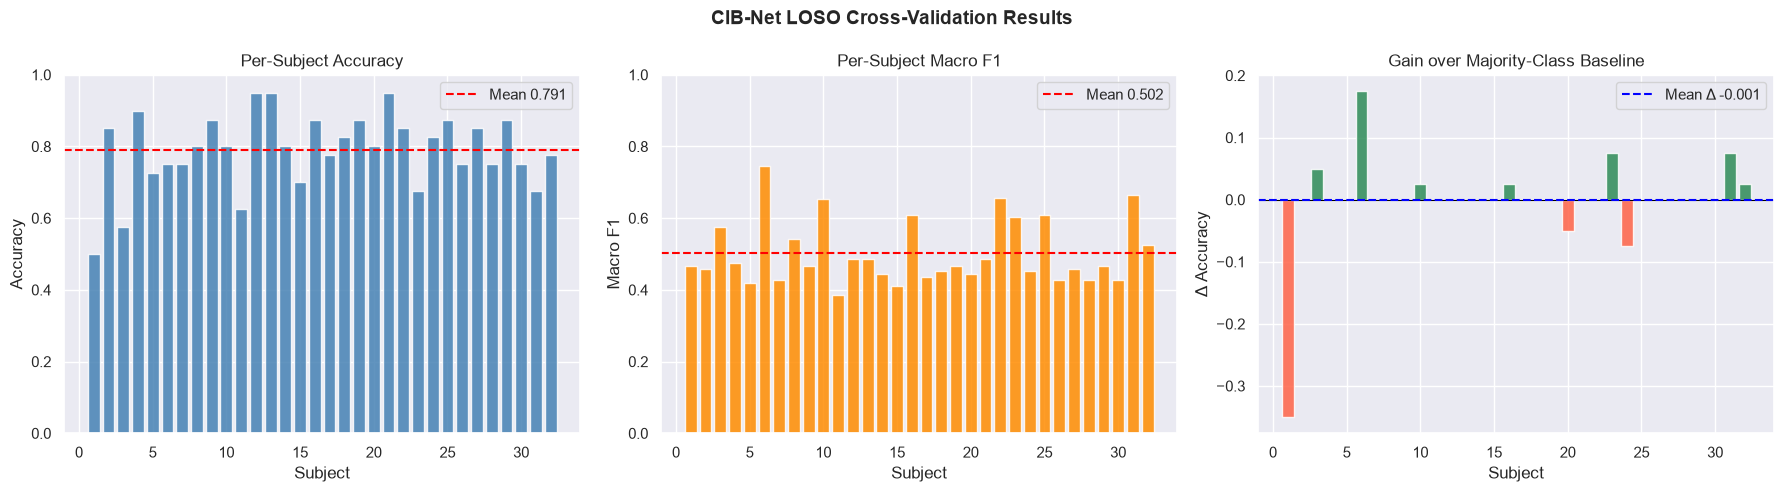

📈  Plot saved → D:/EEG_5Stages/checkpoints\cib_net_results.png


In [13]:
# Load metrics if not in memory (e.g. after kernel restart)
if not fold_metrics and os.path.exists(METRICS_CKPT):
    with open(METRICS_CKPT) as f:
        fold_metrics = json.load(f)

accs   = [m["accuracy"]      for m in fold_metrics]
f1s    = [m["macro_f1"]      for m in fold_metrics]
deltas = [m["delta_trivial"] for m in fold_metrics]

print("=" * 52)
print("  📊  FINAL CIB-NET LOSO RESULTS")
print("=" * 52)
print(f"  Accuracy   : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"  Macro F1   : {np.mean(f1s):.4f}")
print(f"  Δ Trivial  : {np.mean(deltas):+.4f}")
print(f"  Folds Done : {len(fold_metrics)}/32")
print("=" * 52)

# Save final JSON summary
summary = {
    "final_accuracy":      float(np.mean(accs)),
    "final_std":           float(np.std(accs)),
    "final_macro_f1":      float(np.mean(f1s)),
    "final_delta_trivial": float(np.mean(deltas)),
    "n_folds":             len(fold_metrics),
    "fold_metrics":        fold_metrics,
}
out_json = os.path.join(CKPT_DIR, "cib_net_final_results.json")
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n💾  Final results saved → {out_json}")

# ── Plots ─────────────────────────────────────────────────────
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CIB-Net LOSO Cross-Validation Results", fontsize=14, fontweight="bold")

subjs = list(range(1, len(accs) + 1))

axes[0].bar(subjs, accs, color="steelblue", alpha=0.85)
axes[0].axhline(np.mean(accs), color="red", linestyle="--", label=f"Mean {np.mean(accs):.3f}")
axes[0].set(xlabel="Subject", ylabel="Accuracy", title="Per-Subject Accuracy", ylim=(0, 1))
axes[0].legend()

axes[1].bar(subjs, f1s, color="darkorange", alpha=0.85)
axes[1].axhline(np.mean(f1s), color="red", linestyle="--", label=f"Mean {np.mean(f1s):.3f}")
axes[1].set(xlabel="Subject", ylabel="Macro F1", title="Per-Subject Macro F1", ylim=(0, 1))
axes[1].legend()

colors = ["seagreen" if d > 0 else "tomato" for d in deltas]
axes[2].bar(subjs, deltas, color=colors, alpha=0.85)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].axhline(np.mean(deltas), color="blue", linestyle="--",
                label=f"Mean Δ {np.mean(deltas):+.3f}")
axes[2].set(xlabel="Subject", ylabel="Δ Accuracy", title="Gain over Majority-Class Baseline")
axes[2].legend()

plt.tight_layout()
plot_path = os.path.join(CKPT_DIR, "cib_net_results.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"📈  Plot saved → {plot_path}")
